In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os



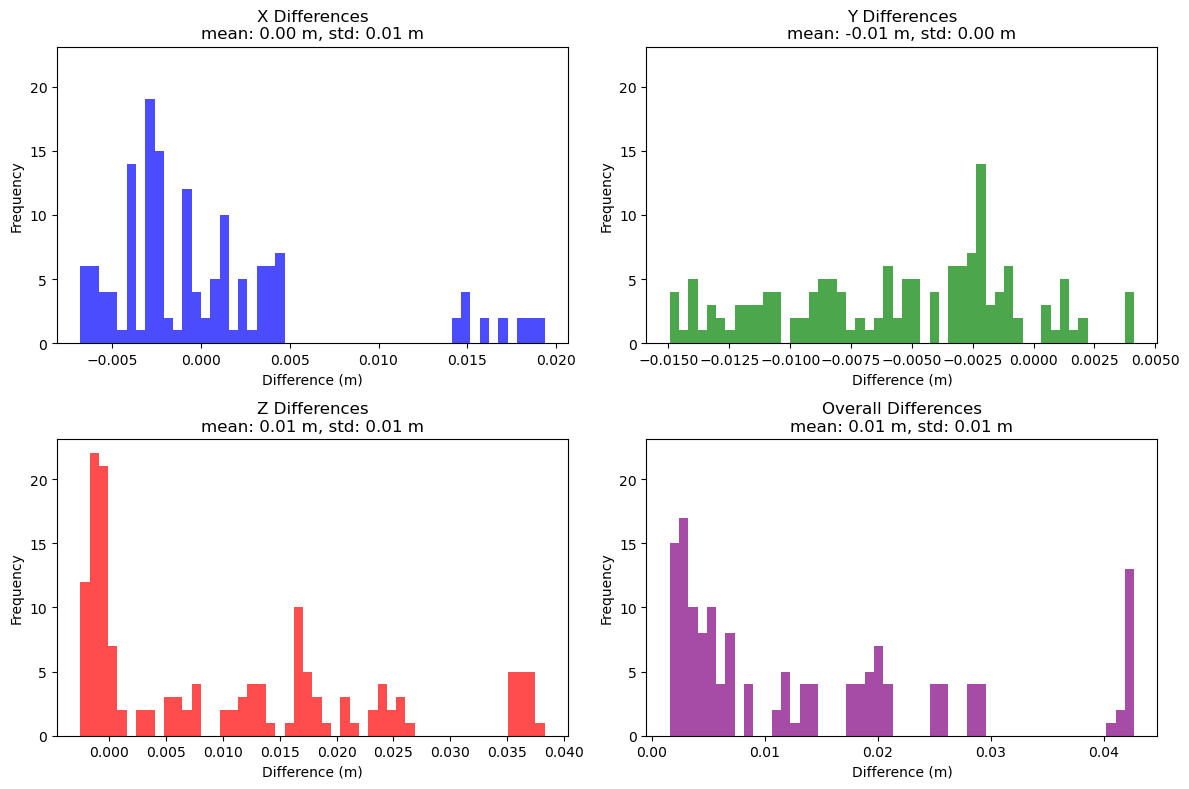

In [23]:
openCSPData_path = r'C:\Users\qzheng\Documents\GitHub\OpenCSP\opencsp\app\scene_reconstruction\test\data\data_measurement_hi_res\point_locations.csv'
photomodeler_path = r"C:\Users\qzheng\Documents\PM_Model2.csv"

openCSPData = pd.read_csv(openCSPData_path, header=0, index_col=None)
photomodelerData = pd.read_csv(photomodeler_path, header=None, index_col=None)


def opencsp_filter_by_marker_id(openCSP_df, id_num):
    # Select a small subset of the data that has matching "# Marker ID"
    filtered_df = openCSP_df[openCSP_df['# Marker ID'] == id_num]
    # only need the last 3 columns, convert to numpy array
    filtered_df = filtered_df.iloc[:, -3:]
    # Convert the DataFrame to a NumPy array
    filtered_array = filtered_df.to_numpy()
    return filtered_array

def photomodeler_filter_by_marker_id(photomodeler_df, id_num):
    id_col = photomodeler_df.iloc[:, 0]
    marker_id_cols  = id_col % 1000
    filtered_df = photomodeler_df[marker_id_cols == id_num]
    filtered_df = filtered_df.iloc[:, -4:-1]  # Select the first three columns after filtering
    return filtered_df.to_numpy()

opencsp_ids = openCSPData['# Marker ID'].unique()
photomodeler_ids = photomodelerData.iloc[:, 0] % 1000
photomodeler_ids = photomodeler_ids.unique()

assert len(opencsp_ids) == len(photomodeler_ids), "Number of unique IDs in OpenCSP and Photomodeler do not match."
distance_buffer = []
x_dist_buffer = []
y_dist_buffer = []
z_dist_buffer = []
for id_num in opencsp_ids:
    photomodeler_pt = photomodeler_filter_by_marker_id(photomodelerData, id_num)
    opencsp_pt = opencsp_filter_by_marker_id(openCSPData, id_num)
    differences = photomodeler_pt - opencsp_pt
    difference_norm = np.linalg.norm(differences, axis=1)
    distance_buffer += list(difference_norm)
    x_dist_buffer += list(differences[:, 0])
    y_dist_buffer += list(differences[:, 1])
    z_dist_buffer += list(differences[:, 2])


# create a 2x2 histogram of the differences
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
axs[0, 0].hist(x_dist_buffer, bins=50, color='blue', alpha=0.7)
axs[0, 0].set_title(f'X Differences\nmean: {np.mean(x_dist_buffer):.2f} m, std: {np.std(x_dist_buffer):.2f} m')
axs[0, 0].set_xlabel('Difference (m)')
axs[0, 0].set_ylabel('Frequency')
axs[0, 1].hist(y_dist_buffer, bins=50, color='green', alpha=0.7)
axs[0, 1].set_title(f'Y Differences\nmean: {np.mean(y_dist_buffer):.2f} m, std: {np.std(y_dist_buffer):.2f} m')
axs[0, 1].set_xlabel('Difference (m)')
axs[0, 1].set_ylabel('Frequency')
axs[1, 0].hist(z_dist_buffer, bins=50, color='red', alpha=0.7)
axs[1, 0].set_title(f'Z Differences\nmean: {np.mean(z_dist_buffer):.2f} m, std: {np.std(z_dist_buffer):.2f} m')
axs[1, 0].set_xlabel('Difference (m)')
axs[1, 0].set_ylabel('Frequency')
axs[1, 1].hist(distance_buffer, bins=50, color='purple', alpha=0.7)
axs[1, 1].set_title(f'Overall Differences\nmean: {np.mean(distance_buffer):.2f} m, std: {np.std(distance_buffer):.2f} m')
axs[1, 1].set_xlabel('Difference (m)')
axs[1, 1].set_ylabel('Frequency')

# fix y axis to be the same for all subplots
max_y = max(ax.get_ylim()[1] for ax in axs.flat)
for ax in axs.flat:
    ax.set_ylim(0, max_y)

plt.tight_layout()
plt.show()

